# Lab: Forecasting Daily Application Volume at the GA Office

## The problem
The Government Affairs office handles a **steady stream of applications** every day — visa renewals, iqamas, family permits, exit/re-entry requests, government letters. Volume is far from constant: it spikes when new students arrive in autumn, drops during Ramadan and the summer break, and dips on public holidays.

To keep service times short, the office needs to **plan staffing a week in advance**. That requires a **forecast** — how many applications will come in each day next week and next month?

In this lab you'll build a forecasting model in just a few lines of code, using **Prophet** (an open-source forecasting tool from Meta).

## What you'll do
1. Look at two years of (synthetic) daily application data.
2. Spot the patterns yourself — weekly rhythm, holidays, semester spikes.
3. Use Prophet to forecast the next several weeks.
4. See how the forecast changes when you adjust the horizon and the holiday calendar.

> Just press ▶ Run on each cell. No coding required.

---


## Step 1 — Install and load Prophet

Prophet is a forecasting library designed for non-experts. It handles trends, weekly cycles, yearly cycles and holidays automatically. The first cell installs it in Colab (takes ~30 seconds).

In [34]:
!pip install -q prophet
print("Prophet installed.")


Prophet installed.


In [35]:
import warnings, logging
warnings.filterwarnings("ignore")

# Quiet down Prophet/CmdStanPy chatter so non-technical learners aren't distracted.
for name in ("cmdstanpy", "prophet"):
    lg = logging.getLogger(name)
    lg.setLevel(logging.ERROR)
    lg.propagate = False
    lg.disabled = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

# Re-disable in case Prophet's import re-enabled the loggers.
for name in ("cmdstanpy", "prophet"):
    logging.getLogger(name).disabled = True

print("Libraries ready.")


Libraries ready.


## Step 2 — Generate two years of daily application data

We simulate a realistic daily series for the GA office over **2023 and 2024**, with:

- a gentle **upward trend** (KAUST is growing — more applicants every year),
- a **weekly cycle** — busy Sun–Thu, very quiet Fri–Sat (Saudi weekend),
- a **yearly cycle** — dips during Ramadan and the summer break, spike in **August / September** when new students and faculty arrive,
- a few **public holidays** (Saudi National Day, Founding Day, Eid),
- random day-to-day **noise**.

In [36]:
def generate_applications(start="2023-01-01", end="2024-12-31", seed=7):
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start, end, freq="D")
    t = np.arange(len(dates))

    # gentle upward trend, baseline ~60 applications/day
    trend = 55 + 0.02 * t

    # Saudi work week: Sun-Thu busy, Fri-Sat weekend.
    # pandas dayofweek: Mon=0, Tue=1, Wed=2, Thu=3, Fri=4, Sat=5, Sun=6.
    dow = np.asarray(dates.dayofweek)
    weekly = np.select(
        [dow == 6, dow == 0, dow == 1, dow == 2, dow == 3, dow == 4, dow == 5],
        [     14,      12,      14,      12,       8,     -45,     -40],
        default=0,
    ).astype(float)

    # yearly seasonality: Ramadan dip + summer dip + Aug-Sep new-semester spike
    doy = np.asarray(dates.dayofyear)
    yearly  = -18.0 * np.exp(-((doy - 80)  / 25) ** 2)      # Ramadan dip
    yearly +=  -10.0 * np.exp(-((doy - 200) / 30) ** 2)     # summer dip
    yearly +=   30.0 * np.exp(-((doy - 240) / 18) ** 2)     # new-semester spike (late Aug)

    holidays = {
        "2023-09-23": -50, "2024-09-23": -50,   # Saudi National Day
        "2023-02-22": -45, "2024-02-22": -45,   # Founding Day
        "2023-04-21": -55, "2024-04-10": -55,   # Eid al-Fitr (approx)
        "2023-06-28": -55, "2024-06-16": -55,   # Eid al-Adha (approx)
    }
    holiday_effect = np.zeros(len(dates))
    for d, eff in holidays.items():
        idx = np.where(dates == pd.Timestamp(d))[0]
        if len(idx):
            holiday_effect[idx[0]] = eff

    noise = rng.normal(0, 5, len(dates))
    visits_arr = trend + weekly + yearly + holiday_effect + noise
    visits = np.clip(visits_arr, 0, None).round().astype(int)

    return pd.DataFrame({"ds": dates, "y": visits})

df = generate_applications()
print(df.head())
print(f"\nRows: {len(df):,}   from {df['ds'].min().date()} to {df['ds'].max().date()}")


          ds   y
0 2023-01-01  69
1 2023-01-02  69
2 2023-01-03  68
3 2023-01-04  63
4 2023-01-05  61

Rows: 731   from 2023-01-01 to 2024-12-31


## Step 3 — Plot the raw data

Before any forecasting, just *look* at the data. Even non-experts can usually spot the patterns by eye.

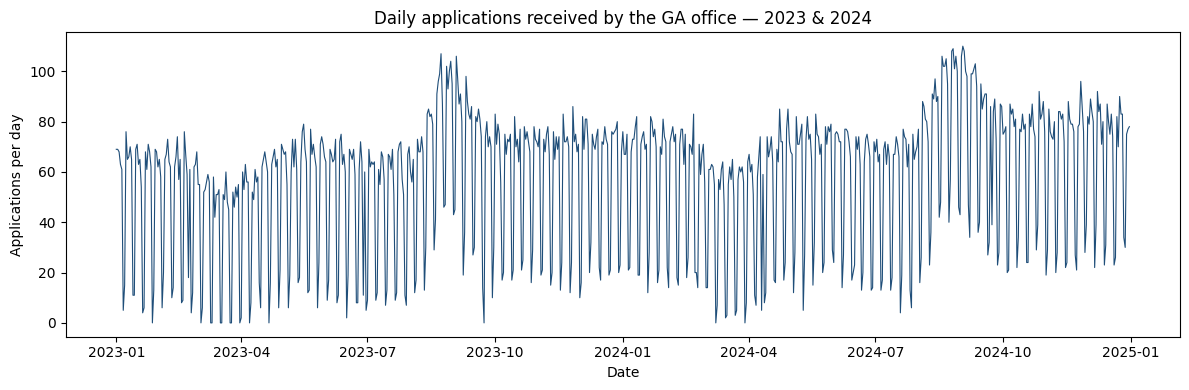

In [37]:
#@title Plot: 2 years of daily applications
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["ds"], df["y"], linewidth=0.8, color="#1f4e79")
ax.set_title("Daily applications received by the GA office — 2023 & 2024")
ax.set_xlabel("Date")
ax.set_ylabel("Applications per day")
plt.tight_layout()
plt.show()


### Zoom in on a single month

The full two-year plot is busy. Let's look at just **one month** so the weekly rhythm is unmistakable. We'll mark Fridays so you can see exactly where the weekend dips fall.

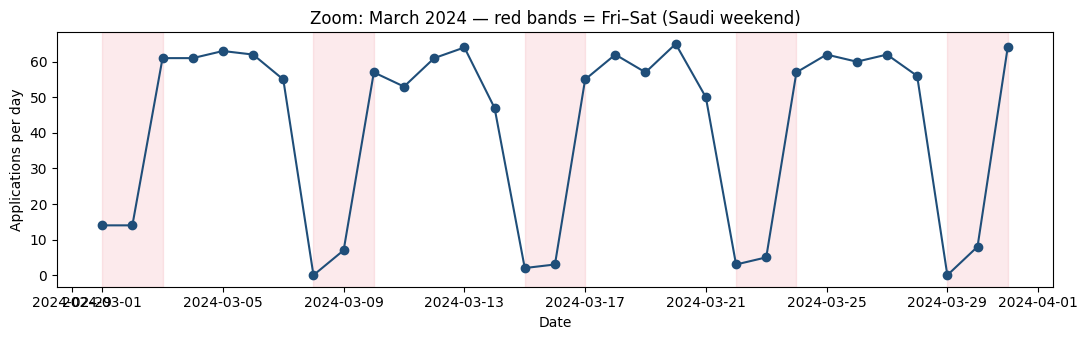

In [38]:
#@title Plot: zoom on March 2024 (Fri–Sat shaded)
sample = df[(df["ds"] >= "2024-03-01") & (df["ds"] <= "2024-03-31")].copy()
fridays = sample[sample["ds"].dt.dayofweek == 4]["ds"]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sample["ds"], sample["y"], marker="o", color="#1f4e79")
for f in fridays:
    ax.axvspan(f, f + pd.Timedelta(days=2), color="#e63946", alpha=0.10)
ax.set_title("Zoom: March 2024 — red bands = Fri–Sat (Saudi weekend)")
ax.set_xlabel("Date"); ax.set_ylabel("Applications per day")
plt.tight_layout(); plt.show()


### Average by day of the week

Group every day in the dataset by its day of the week, then take the average. The pattern jumps out: Sun–Thu are working days, Fri–Sat are the weekend.

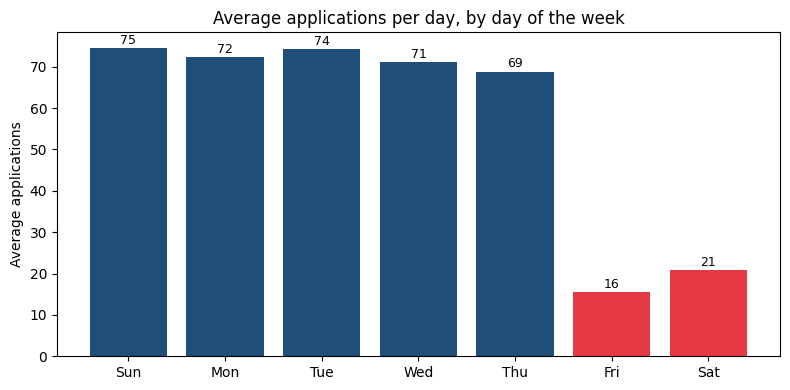

In [39]:
#@title Plot: average applications by day of the week
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df_dow = df.assign(dow=df["ds"].dt.dayofweek)
avg_by_dow = df_dow.groupby("dow")["y"].mean().reindex([6, 0, 1, 2, 3, 4, 5])  # Sun first
labels      = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

colors = ["#1f4e79"] * 5 + ["#e63946"] * 2   # Sun-Thu blue, Fri-Sat red
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, avg_by_dow.values, color=colors)
ax.set_title("Average applications per day, by day of the week")
ax.set_ylabel("Average applications")
for i, v in enumerate(avg_by_dow.values):
    ax.text(i, v + 1, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


### Average by month of the year

Now group by month. This reveals the **yearly** pattern: a quiet stretch around Ramadan and the summer, and a clear surge in **August–September** when new students and faculty arrive at KAUST.

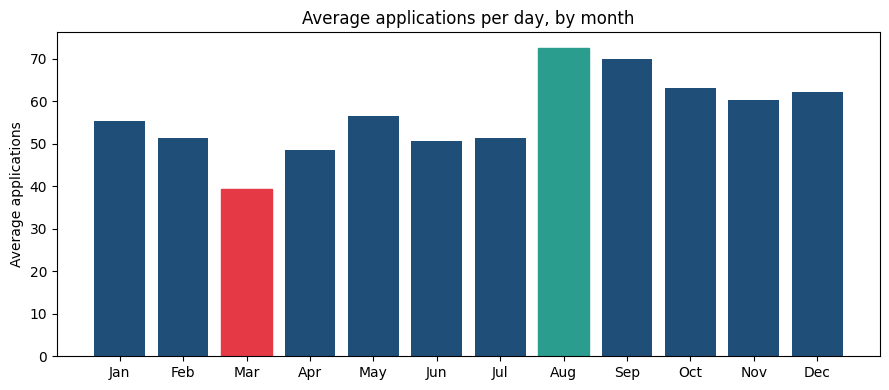

Busiest month:  Aug  (73 apps/day on average)
Quietest month: Mar  (39 apps/day on average)


In [40]:
#@title Plot: average applications by month
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
avg_by_month = df.assign(month=df["ds"].dt.month).groupby("month")["y"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(month_names, avg_by_month.values, color="#1f4e79")
peak = int(avg_by_month.idxmax()) - 1
trough = int(avg_by_month.idxmin()) - 1
bars[peak].set_color("#2a9d8f")     # busiest month — green
bars[trough].set_color("#e63946")   # quietest month — red
ax.set_title("Average applications per day, by month")
ax.set_ylabel("Average applications")
plt.tight_layout(); plt.show()

print(f"Busiest month:  {month_names[peak]}  ({avg_by_month.iloc[peak]:.0f} apps/day on average)")
print(f"Quietest month: {month_names[trough]}  ({avg_by_month.iloc[trough]:.0f} apps/day on average)")


### A few summary numbers

Before we hand the data to the model, it's good practice to sanity-check the basics.

In [41]:
busiest = df.loc[df["y"].idxmax()]
quietest = df.loc[df["y"].idxmin()]

print(f"Total days in dataset:   {len(df):,}")
print(f"Average applications:    {df['y'].mean():.1f} per day")
print(f"Range:                   {df['y'].min()} to {df['y'].max()} per day")
print()
print(f"Busiest single day:      {busiest['ds'].date()}  ({busiest['y']} applications)")
print(f"Quietest single day:     {quietest['ds'].date()}  ({quietest['y']} applications)")


Total days in dataset:   731
Average applications:    56.9 per day
Range:                   0 to 110 per day

Busiest single day:      2024-09-02  (110 applications)
Quietest single day:     2023-01-27  (0 applications)


**What can you spot?**

- A clear **weekly rhythm** (the dense up-and-down: Sun–Thu busy, Fri–Sat quiet).
- Sharp **single-day dips** on national holidays.
- A broader **dip during Ramadan and the summer**.
- A clear **spike each August / September** when new students and faculty arrive.
- A subtle **upward drift** over the two years, as KAUST grows.

The forecasting model's job is to learn all of these patterns automatically.

## Step 4 — Fit a Prophet model

This is the whole forecasting model — five lines of code. We give Prophet our historical data, ask for the next 60 days, and plot the result.

The shaded band around the forecast is the model's **uncertainty interval** — wider means "less sure".

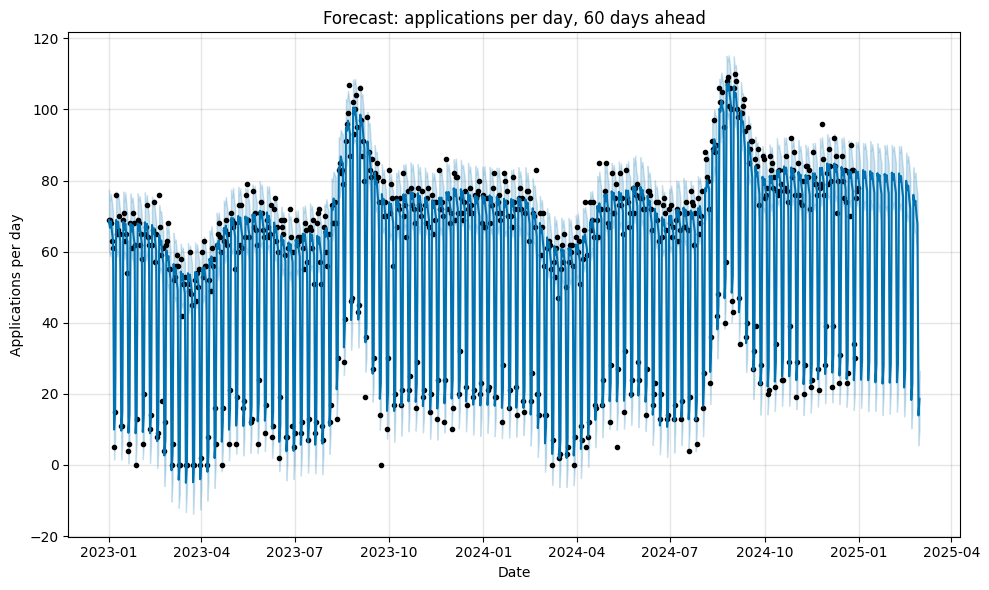

In [42]:
#@title Forecast: applications per day, 60 days ahead
model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
model.fit(df)

future = model.make_future_dataframe(periods=60)   # forecast 60 days ahead
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Forecast: applications per day, 60 days ahead")
plt.xlabel("Date"); plt.ylabel("Applications per day")
plt.tight_layout()
plt.show()


## Step 5 — Open the black box: components

Prophet doesn't just give us a single forecast line — it can show us **what makes up that forecast**. The chart below has three panels:

1. **Trend** — the slow underlying growth or decline.
2. **Weekly** — the average effect of each day of the week.
3. **Yearly** — the average effect of each part of the year.

Look at the **weekly** panel: you should see Fri–Sat well below zero (Saudi weekend) and Sun–Thu above. That's the model recovering the rhythm from the data on its own. In the **yearly** panel, look for the August–September peak.

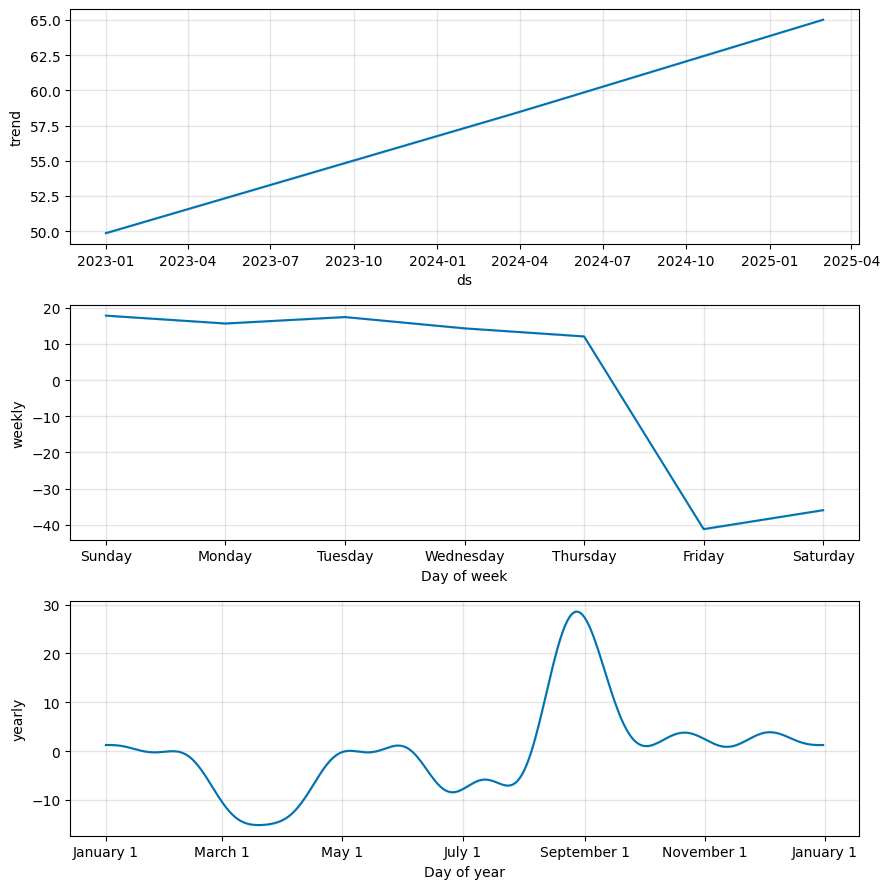

In [43]:
#@title Forecast components: trend / weekly / yearly
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()


## Step 6 — Try different forecast settings

Use the form on the right of the cell below to:

- **Change the forecast horizon** — how many days into the future to predict.
- **Toggle Saudi holidays** — whether the model knows about the public holidays in our calendar.

Run the cell after each change and watch how the forecast updates. With holidays turned **on**, the model should produce visible dips on those dates; with them off, the line stays smoother and overestimates demand on holidays.

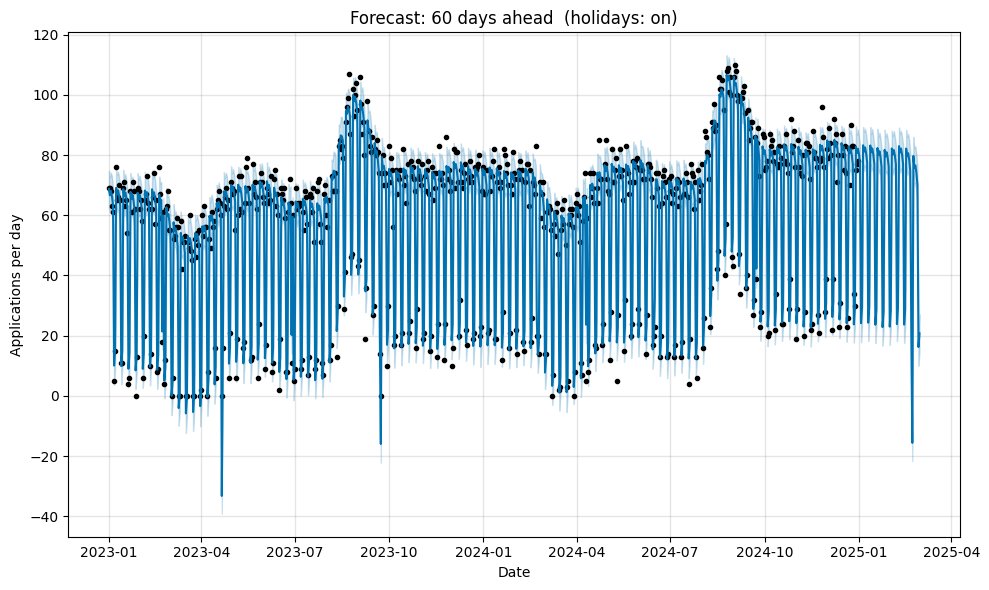

In [44]:
#@title Forecast settings { run: "auto" }
forecast_horizon_days = 60   #@param {type:"slider", min:7, max:120, step:1}
include_saudi_holidays = True  #@param {type:"boolean"}

saudi_holidays = pd.DataFrame({
    "holiday": "saudi_public_holiday",
    "ds": pd.to_datetime([
        "2023-02-22", "2024-02-22", "2025-02-22",   # Founding Day
        "2023-04-21", "2024-04-10", "2025-03-30",   # Eid al-Fitr (approx)
        "2023-06-28", "2024-06-16", "2025-06-06",   # Eid al-Adha (approx)
        "2023-09-23", "2024-09-23", "2025-09-23",   # Saudi National Day
    ]),
    "lower_window": 0,
    "upper_window": 1,
})

m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=saudi_holidays if include_saudi_holidays else None,
)
m.fit(df)

future = m.make_future_dataframe(periods=int(forecast_horizon_days))
forecast = m.predict(future)

fig = m.plot(forecast)
plt.title(f"Forecast: {forecast_horizon_days} days ahead  "
          f"(holidays: {'on' if include_saudi_holidays else 'off'})")
plt.xlabel("Date"); plt.ylabel("Applications per day")
plt.tight_layout()
plt.show()


## Step 7 — Is the forecast any good? (Backtest)

So far Prophet has drawn a confident-looking line into the future. But how do we know it's *accurate*?

The standard answer is a **backtest**: train the model on data it has seen (2023) and ask it to predict data it hasn't (2024) — then compare the prediction to what actually happened.

Below, the **blue line** is what really happened in 2024, and the **red line** is what the model predicted, having only seen 2023. The shaded red band is the model's uncertainty interval. The number we care about is **MAE** — the average error in applications-per-day.


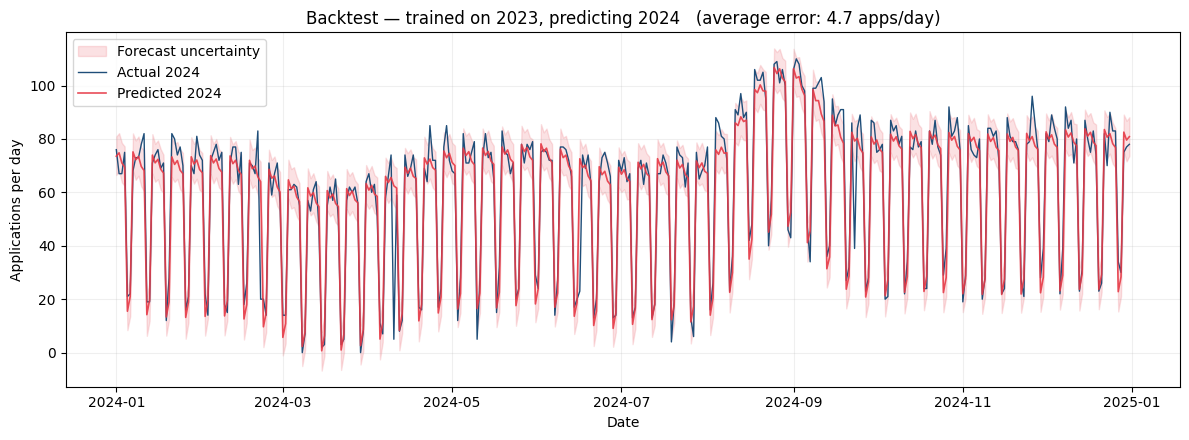

Average error (MAE):  4.7 applications per day
Daily average volume: 56.9 applications per day
So the typical forecast is off by about 8% of a normal day's volume.


In [45]:
#@title Backtest: train on 2023, see how well it predicts 2024
train = df[df["ds"] <  "2024-01-01"].reset_index(drop=True)
test  = df[df["ds"] >= "2024-01-01"].reset_index(drop=True)

m_bt = Prophet(weekly_seasonality=True, yearly_seasonality=True)
m_bt.fit(train)

future_bt = m_bt.make_future_dataframe(periods=len(test), include_history=False)
fc_bt = m_bt.predict(future_bt)

merged = test.merge(fc_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
mae = (merged["y"] - merged["yhat"]).abs().mean()
mean_y = df["y"].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(merged["ds"], merged["yhat_lower"], merged["yhat_upper"],
                color="#e63946", alpha=0.15, label="Forecast uncertainty")
ax.plot(merged["ds"], merged["y"],    label="Actual 2024",    color="#1f4e79", linewidth=1.0)
ax.plot(merged["ds"], merged["yhat"], label="Predicted 2024", color="#e63946", linewidth=1.2, alpha=0.9)
ax.set_title(f"Backtest — trained on 2023, predicting 2024   (average error: {mae:.1f} apps/day)")
ax.set_xlabel("Date"); ax.set_ylabel("Applications per day")
ax.legend(loc="upper left"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f"Average error (MAE):  {mae:.1f} applications per day")
print(f"Daily average volume: {mean_y:.1f} applications per day")
print(f"So the typical forecast is off by about {mae/mean_y*100:.0f}% of a normal day's volume.")


**What this tells us**

The model never saw 2024 during training, yet it traces the actual blue line surprisingly well — including the weekend dips, the Ramadan/summer slowdowns, and the August spike. The remaining error (the gap between the lines) is the part the model *can't* predict: random day-to-day noise, ad-hoc events, ministry portal outages.

A typical guideline: if MAE is below ~10–15% of daily average volume, the forecast is usable for staff planning. Anything higher means we need more data or a richer model.


## Step 8 — Translate the forecast into a staffing plan

A forecast is only useful if it changes a decision. The chart below takes the **next 14 days** of the forecast you just produced and turns it into something an office manager can act on:

- The **bar height** is the expected number of applications per day.
- **Red bars** are Saudi weekend days (Fri–Sat).
- The number on each bar is the **suggested staff count** for that day, assuming one reviewer can comfortably process about 8 applications per day.

Adjust the `apps_per_staff_per_day` setting in the form to match your real capacity.


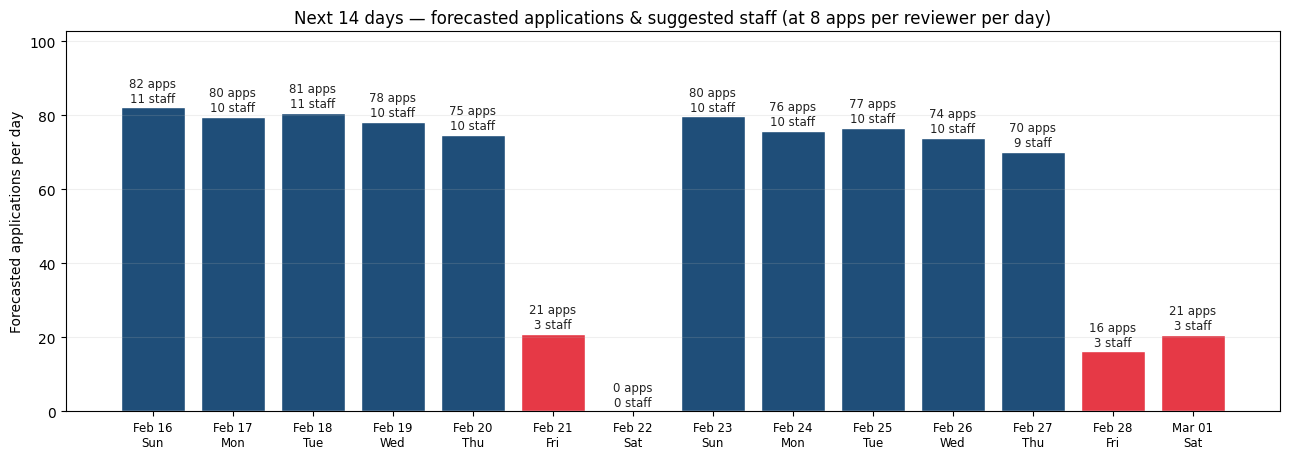

Forecasted volume next 14 days: ~830 applications
Total staff-days needed:        110
Peak day:                       2025-02-16 (82 apps -> 11 staff)


In [46]:
#@title Operational view: next 14 days — forecast & suggested staff
apps_per_staff_per_day = 8  #@param {type:"slider", min:3, max:20, step:1}

next14 = forecast.tail(14).copy().reset_index(drop=True)
next14["weekday"]   = next14["ds"].dt.day_name().str.slice(0, 3)
next14["is_weekend"] = next14["ds"].dt.dayofweek.isin([4, 5])
next14["yhat_pos"]   = next14["yhat"].clip(lower=0)
next14["staff_needed"] = np.ceil(next14["yhat_pos"] / apps_per_staff_per_day).astype(int)

fig, ax = plt.subplots(figsize=(13, 4.7))
colors = ["#e63946" if w else "#1f4e79" for w in next14["is_weekend"]]
ax.bar(range(len(next14)), next14["yhat_pos"], color=colors, edgecolor="white")
ax.set_xticks(range(len(next14)))
ax.set_xticklabels(
    [f"{d.strftime('%b %d')}\n{w}" for d, w in zip(next14['ds'], next14['weekday'])],
    fontsize=8.5,
)
for i, (v, s) in enumerate(zip(next14["yhat_pos"], next14["staff_needed"])):
    ax.text(i, v + 1.5, f"{int(round(v))} apps\n{s} staff",
            ha="center", fontsize=8.5, color="#222")
ax.set_title(f"Next 14 days — forecasted applications & suggested staff "
             f"(at {apps_per_staff_per_day} apps per reviewer per day)")
ax.set_ylabel("Forecasted applications per day")
ax.set_ylim(0, max(next14["yhat_pos"]) * 1.25)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()

total_apps  = int(round(next14["yhat_pos"].sum()))
total_staff_days = int(next14["staff_needed"].sum())
peak_row   = next14.loc[next14["yhat_pos"].idxmax()]
print(f"Forecasted volume next 14 days: ~{total_apps} applications")
print(f"Total staff-days needed:        {total_staff_days}")
print(f"Peak day:                       {peak_row['ds'].date()} "
      f"({int(round(peak_row['yhat_pos']))} apps -> {peak_row['staff_needed']} staff)")


**From numbers to a roster**

The chart turns the forecast into the only thing the office actually needs: *how many people on which days*. The slider above lets you change the workload assumption (e.g. complex visa cases take longer, so fewer apps per reviewer; routine renewals are faster, so more).

In a real deployment this view would feed directly into the weekly staff schedule, with two human checks before the schedule is published:
1. Are the upcoming days near a known event the model doesn't know about (a new ministry policy, a campus-wide deadline)?
2. Does the suggested headcount fit within budget and leave / sick-day buffers?


## What this means for the GA office

- A forecast like this turns **staff scheduling and capacity planning** from gut feeling into an evidence-based decision.
- Prophet is intentionally simple — five lines of code give a usable forecast. It's a good *first* tool, not the last word.
- A real deployment would need:
  - **Real historical application logs**, ideally several years and broken down by application type.
  - **An accurate calendar** (Saudi public holidays, KAUST academic calendar, ministry portal outages).
  - **Regular re-training** as patterns shift (new programs, KAUST growth, new ministry rules).
  - **Monitoring** — compare forecast vs. actual every week, and act when the model drifts.

The forecast is the easy part. The value comes from **acting** on it: matching staff rosters, prioritising urgent applications during expected peaks, and communicating realistic timelines to faculty and students.